# Генераторы событий

В языке Python есть мощная концепция под названием *итерируемый объект* - это любой объект (класс), который реализует *протокол итератора*.
О протоколе итератора подробно рассказано [здесь](https://unexpectedcoder.github.io/sm6-py-cookbook/discrete-event.html) и [на хабре](https://habr.com/ru/articles/488112/).
Здесь рассмотрим данный протокол минимально, но достаточно.
Это необходимо для понимания концепции *функции-генератора* в Python.

## Протокол итератора

Посмотрим, как устроен протокол итератора "на пальцах".

Список, кортеж, словарь, множество и генератор - примеры итерируемых объектов в Python.
Пусть есть список `a`:

In [1]:
a = [1, 'a', None, False, -3.5]

Когда мы желаем пройтись по списку (другими словами, хотим *итерировать* список), то пишем что-то в таком духе:

In [2]:
for ai in a:
    print(ai)

1
a
None
False
-3.5


Ровно то же самое можно получить с помощью явного итератора списка:

In [3]:
# Создаём итератор по списку a
a_iter = iter(a)
# И итерируем вручную с помощью встроенной функции next
print(next(a_iter))

1


In [4]:
print(next(a_iter))

a


И так далее до последнего элемента.
Но что случится, если мы, дойдя до конца итерируемой коллекции (итератора), вновь применим функцию `next(...)`?
Случится исключение `StopIteration`.
Собственно, так и работает цикл `for`.
Можно переписать его через цикл `while`:

In [5]:
a_iter = iter(a)
while True:
    try:
        print(next(a_iter))
    except StopIteration:
        break

1
a
None
False
-3.5


Получен ровно тот же результат.

С помощью итераторов возможно создание собственных (пользовательских) классов, поддерживающих протокол итератора, путём описания методов `__iter__(self)` (возвращает итератор для объекта) и `__next__(self)` (возвращает элемент коллекции).

## Генераторы

Как уже было отмечено, среди итерируемых сущностей в Python существуют так называемые *генераторы*.
Что они собой представляют?
Это обычная Python-функция с единственной особенностью - в её теле есть один или несколько операторов `yield`.
Вот пример:

In [6]:
def count(start, stop, step):
    """Генератор, выдающий числа по порядку
    от 0 до бесконечности.
    """
    counter = start
    while counter <= stop:
        yield counter
        counter += step

Это функция, создающая генератор с помощью оператора `yield`.

In [7]:
# Создание генератора
count_gen = count(start=1, stop=5, step=1)
# Генерация чисел
for x in count_gen:
    print(x)

1
2
3
4
5


Можно то же самое записать более лаконично:

In [8]:
for x in count(1, 5, 1):
    print(x)

1
2
3
4
5


По аналогичной схеме действуют такие встроенные и часто применяемые функции, как `range(...)`, `enumerate(...)`, `zip(...)` и другие (особенно из пакета `itertools`).

Механику генератора упрощённо можно выразить следующим образом:

1. Вызывается функция, создающая генератор.
   Будем рассматривать в качестве примера `count(...)`.
2. Функция выполняется до первого оператора `yield`, после чего возвращает управление и объект генератора вызвавшему её коду.
3. Каждый раз, когда к генератору применяется функция `next(...)`, генерируется значение, указанное у оператора `yield`.
   В данном случае `yield counter` будет возвращать текущее значение счётчика.
4. После этого выполняется тело функции после оператора `yield` (если оно есть, в ином случае по умолчанию срабатывает `return None`).
   Именно поэтому в `count(...)` бесконечный цикл не выполняется непрерывно.

Два главных преимущества генераторов обусловлены экономией памяти и естественным механизмом сохранения внутреннего состояния генератором.
Последнее означает, что все аргументы и локальные переменные порождающей функции сохраняются внутри генератора, пока он активный (действующий).
Генератор перестаёт быть активным, если из него осуществляется выход оператором `return <value>`.
Генератор от функции отличается только поддержкой протокола итератора.
В остальном он ведёт себя, как любая Python-функция.

И всё это именно то, что нам нужно, чтобы облегчить написание кода дискретно-событийных моделей!

## Процессы как генераторы событий

Раз генераторы могут сохранять свои локальные переменные и параметры, заданные при их создании, то отпадает необходимость в явном указании действии при инициализации событий.
Теперь действие - это всё то, что находится после оператора `yield` в теле функции процесса, ведь код после `yield` выполняется, когда к генератору применяется функция `next(...)`, что происходит в основном цикле моделирования при наступлении события.
Далее на примере кода смысл написанного прояснится.

Наш класс события `Timeout` приобретает совсем простую форму:

In [9]:
import numpy as np


def calc_delay(bounds, r, v):
    # Распакуем аргументы для удобства
    (x_lb, x_rb), (y_bb, y_tb) = bounds
    x, y = r
    vx, vy = v
    # Вычисляем время (задержку):
    dtx, dty = 0., 0.
    # - в направлении оси Ox
    if vx > 0:
        dtx = (x_rb - x) / vx
    elif vx < 0:
        dtx = (x_lb - x) / vx
    # - в направление оси Oy
    if vy > 0:
        dty = (y_tb - y) / vy
    elif vy < 0:
        dty = (y_bb - y) / vy
    # Определяем, какую проекцию скорости инвертировать
    signs = [1, 1]
    signs[np.argmin((dtx, dty))] = -1
    return min(dtx, dty), signs

In [10]:
from dataclasses import dataclass

@dataclass(order=True, frozen=True)
class Timeout:
    when: float

В нём теперь нет поля `actions`, хранящего список кортежей пар `(функция, аргументы)`.

Функции расчёта столкновений шарика со стенками `calc_delay(...)` и обновления его параметров и траектории `update(...)` нисколько не изменились.
А вот как теперь выглядит процесс движения шарика:

In [11]:
def ball_motion(env, bounds, r, v, traj):
    """Генератор событий столкновения шарика
    со стенками.
    """
    while True:
        dt, signs = calc_delay(bounds, r, v)
        yield env.timeout(dt)
        # Действия
        # (избавились от отдельной функции update)
        r += v * dt
        v *= signs
        traj.append((env.now, *r))

Также отличие есть в методе `env.timeout(...)`.
Теперь ему не нужно передавать список действий с аргументами.
Это упрощает сопровождение программы (поиск ошибок, добавление чего-либо нового в модель и т.д.) и делает код более читаемым и выразительным.

Также из нового можно отметить использование бесконечного цикла `while True`, что, как мы уже знаем, для генератора означает лишь, что он будет работать (генерировать) столько, сколько нам потребуется.
Это то, к чему ранее приводило указание функции того же самого процесса в списке действий.

Как же теперь запишется основной цикл ДСМ?

## Основной цикл моделирования

Разберёмся, что изменилось в среде моделирования.
Набор полей и методов не изменился, но теперь методы `process(...)` и `run(...)` работают не с функциями, а с генераторами посредством итераторов.
Вот как теперь выглядит класс среды моделирования:

In [12]:
from queue import PriorityQueue


class Environment:
    """Класс среды дискретно-событийного моделирования.
    """
    # Инициализатор остался тем же самым
    def __init__(self):
        self.now = 0
        self.processes = []
        self.events = PriorityQueue()
    
    # В список процессов добавляем не просто
    # генератор, а его итератор
    def process(self, proc):
        """Инициализация процесса.
        Здесь proc - это генератор событий.
        """
        self.processes.append(iter(proc))
    
    # timeout стал чуть проще
    # из-за меньшего числа аргументов
    def timeout(self, delay):
        """Создание события Timeout.
        """
        self.events.put(Timeout(self.now + delay))
    
    # Цикл моделирования претерпел изменения,
    # связанные с работой с генераторами
    def run(self, until):
        """Основной цикл моделирования.
        """
        while True:
            # Генерация событий теперь происходит,
            # когда к итераторам процессов применяется
            # функция next
            for proc in self.processes:
                try:
                    next(proc)
                    # После этого будет выполнен код
                    # в proc после yield, т.е. будут
                    # выполнены все действия
                except StopIteration:
                    # Это значит, что процесс
                    # (генератор) закончился, поэтому
                    # его стоит убрать из списка
                    self.processes.remove(proc)

            # Далее всё то же, что и было, кроме того,
            # что теперь нет нужды запускать функции
            # действий напрямую
            if self.events.empty():
                break

            event = self.events.get()
            if event.when > until:
                break

            self.now = event.when

Основное отличие, как можно заметить, состоит в работе с итераторами генераторов событий, а не напрямую с функциями процессов и действий.
Здесь важно понимать, как работает связка генератор-итератор-`next`.

Сначала в `run(...)` посредством `next(...)` делается попытка запустить все заданные процессы (`iter` процессы не запускает, а лишь создаёт итератор).

Если процесс завершён (возникло исключение `StopIteration`), то этот процесс удаляется из списка процессов.
Цикл `for` продолжается.

В противном случае над итератором процесса выполняется функция `next(...)`, в результате чего поток управления Python возвращается в функцию-генератор в то место, где расположен оператор `yield`.
Выполняется весь дальнейший код функции до следующей встречи с `yield`.
В случае процесса `ball_motion(...)` выполнится действие `update(...)`, начнётся следующая итерация бесконечного цикла, вызовется функция `calc_delay(...)` и снова функция упрётся в оператор `yield`, вернув управление вызвавшему коду (методу `run(...)`).

Теперь посмотрим, как инициализировать и запустить моделирование.

## Моделирование

Условие задачи то же, что было ранее:

In [13]:
box_xy, box_w, box_h = (0, 0), 1, 1
bounds = (box_xy[0], box_w), (box_xy[1], box_h)
r = np.array((0.6, 0.3))
v = np.array((0.3, 0.1))
until = 59

Запуск моделирования выглядит похоже, но имеет одну важную особенность:

In [14]:
env = Environment()
traj = [(env.now, *r)]
# Особенность в том, что в метод process передаётся
# не имя функции, а генератор, который создаётся
# при вызове функции-генератора
env.process(ball_motion(env, bounds, r, v, traj))
env.run(until)

Функция-генератор `ball_motion(...)` возвращает объект генератора, хранящий все переданные этой функции параметры.

Обработка результатов нисколько не меняется.
В итоге получается ровно то же самое решение, что и во всех предыдущих разделах.

На этом, пожалуй, закончим рассматривать основы программной реализации ДСМ.
Намеченная цель - разобраться с основами ДСМ и программно реализовать алгоритм ДСМ - достигнута.
Теперь вы знаете и теорию ДСМ, и то, как его можно реализовать на практике.

Не забывайте, что Python является ходовым инструментом у учёных и инженеров из самых разных областей, поэтому неудивительно, что имеется готовый мощный инструмент для ДСМ.
Называется он SimPy (существуют и другие решения).
Конечно, не стоит изобретать собственный велосипед.
В данной главе алгоритм ДСМ реализовывался с нуля исключительно в учебных целях, чтобы вы увидели, что никакой магии нет ни в самом ДСМ, нет её и внутри SimPy.

Далее перейдём к рассмотрению библиотеки SimPy, основанной на генераторах событий.
К концепции SimPy мы максимально приблизились, так что освоение этой библиотеки не вызовет у вас трудностей.
На примере SimPy узнаем, какие ещё фантастические твари обитают в дискретно-событийном мире.

## Исходный код

Число столкновений: 25


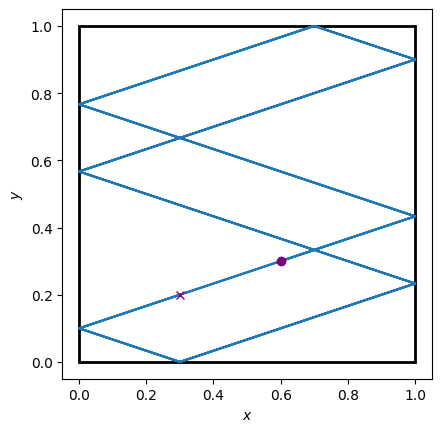

In [15]:
import matplotlib.pyplot as plt
import numpy as np

from dataclasses import dataclass
from matplotlib.patches import Rectangle
from typing import Union
from queue import PriorityQueue


@dataclass(order=True, frozen=True)
class Timeout:
    when: Union[int, float]


class Environment:
    def __init__(self):
        self.now = 0
        self.processes = []
        self.events = PriorityQueue()
    
    def process(self, proc):
        self.processes.append(iter(proc))
    
    def timeout(self, delay):
        self.events.put(Timeout(env.now + delay))
    
    def run(self, until):
        while True:
            for proc in self.processes:
                try:
                    next(proc)
                except StopIteration:
                    self.processes.remove(proc)
            if self.events.empty():
                break

            event = self.events.get()
            if event.when > until:
                break

            self.now = event.when


def ball_motion(env: Environment, bounds, r, v, traj):
    while True:
        dt, signs = calc_delay(bounds, r, v)
        yield env.timeout(dt)
        update(env, dt, signs, traj, r, v)


def calc_delay(bounds, r, v):
    # Распакуем аргументы для удобства
    (x_lb, x_rb), (y_bb, y_tb) = bounds
    x, y = r
    vx, vy = v
    # Вычисляем время (задержку):
    dtx, dty = 0., 0.
    # - в направлении оси Ox
    if vx > 0:
        dtx = (x_rb - x) / vx
    elif vx < 0:
        dtx = (x_lb - x) / vx
    # - в направление оси Oy
    if vy > 0:
        dty = (y_tb - y) / vy
    elif vy < 0:
        dty = (y_bb - y) / vy
    # Определяем, какую проекцию скорости инвертировать
    signs = [1, 1]
    signs[np.argmin((dtx, dty))] = -1
    return min(dtx, dty), signs


def update(env: Environment, dt, signs, traj, r, v):
    r += v * dt
    v *= signs
    traj.append((env.now, *r))


def plot_traj(traj, figax=None, **kw):
    if figax is None:
        fig, ax = plt.subplots()
    else:
        fig, ax = figax
    # Линии траектории
    ax.plot(traj[:, 1], traj[:, 2], **kw)
    # Начальная и конечная точки
    ax.plot(traj[0, 1], traj[0, 2],
            ls="", marker="o", c="purple")
    ax.plot(traj[-1, 1], traj[-1, 2],
            ls="", marker="x", c="purple")
    return fig, ax


# Условия задачи
box_xy, box_w, box_h = (0, 0), 1, 1
bounds = (box_xy[0], box_w), (box_xy[1], box_h)
r = np.array((0.6, 0.3))
v = np.array((0.3, 0.1))
until = 59

# Решение
env = Environment()
traj = [(env.now, *r)]
env.process(ball_motion(env, bounds, r, v, traj))
env.run(until)

# Сохраняем конечную точку траектории
r += v*(until - traj[-1][0])
traj.append((env.now, *r))
traj = np.array(traj)

# Графики
fig, ax = plot_traj(traj)
bounds_rect = Rectangle(
    box_xy, box_w, box_h,
    facecolor="none", edgecolor="k", lw=2
)
ax.add_patch(bounds_rect)
ax.set(xlabel="$x$", ylabel="$y$", aspect="equal")

print("Число столкновений:", traj.shape[0] - 1)
plt.show()